In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
from sklearn.preprocessing import OrdinalEncoder
ordi = OrdinalEncoder()
df[['sex','smoker']] = ordi.fit_transform(df[['sex','smoker']])

In [5]:
df = pd.get_dummies(df,'region',drop_first = True,dtype = 'int')

In [6]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0.0,27.900,0,1.0,16884.92400,0,0,1
1,18,1.0,33.770,1,0.0,1725.55230,0,1,0
2,28,1.0,33.000,3,0.0,4449.46200,0,1,0
3,33,1.0,22.705,0,0.0,21984.47061,1,0,0
4,32,1.0,28.880,0,0.0,3866.85520,1,0,0


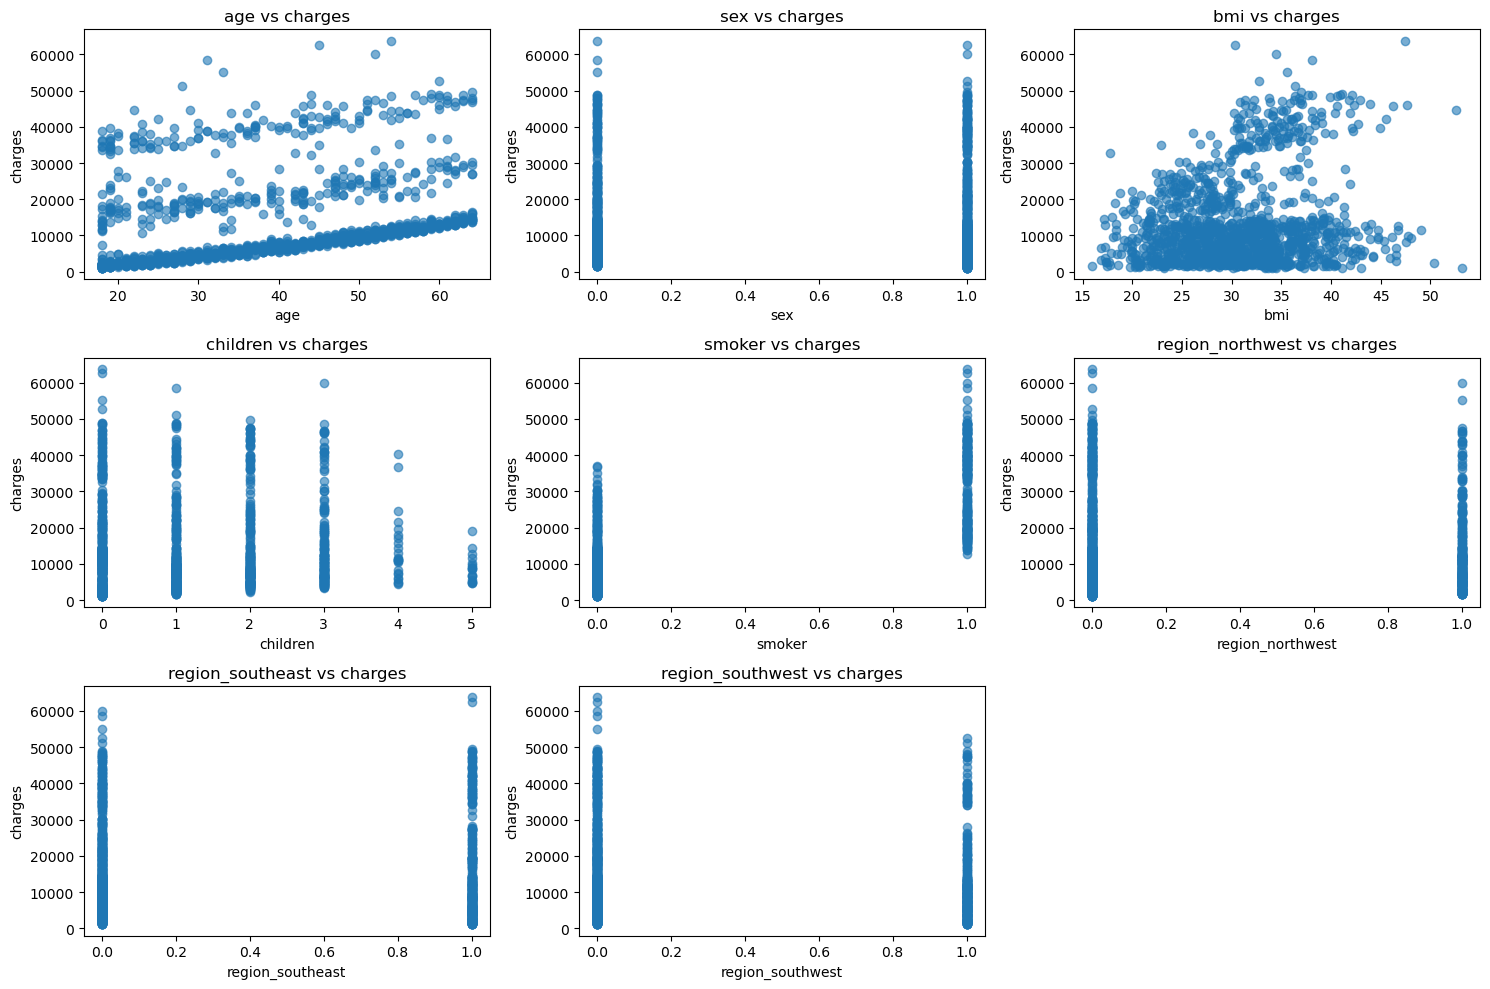

In [7]:
import matplotlib.pyplot as plt

target = 'charges'

# Target column ko hata do
features = df.drop(columns=[target]).columns

# Figure size
plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df[col], df[target], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f'{col} vs {target}')

plt.tight_layout()
plt.show()

In [15]:
X = df.drop(columns = 'charges')
y = df['charges']

In [17]:
# first we apply only linear regression

from sklearn.model_selection import cross_val_score,KFold
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
fold = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 13
)
scores = cross_val_score(lr,X,y,cv = fold,scoring = 'r2')
print(scores)
print(scores.mean())

[0.79906379 0.70578374 0.70916111 0.76694665 0.74015912]
0.7442228818457679


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [19]:
# apply polynomial features of degree 2 
# but you can chosse any degress

poly = PolynomialFeatures(degree = 2,include_bias = False)
X_transform = poly.fit_transform(X)

In [22]:
from sklearn.model_selection import cross_val_score,KFold
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
fold = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 13
)
scores = cross_val_score(lr,X_transform,y,cv = fold,scoring = 'r2')
print(scores)
print(scores.mean())

# after applying the polynomial features accuracy is increased 

[0.89474953 0.81844101 0.82328469 0.82940722 0.81615017]
0.8364065241480683


In [20]:
X.head(1)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0.0,27.9,0,1.0,0,0,1


In [12]:
X_transform[0]

array([ 19.  ,   0.  ,  27.9 ,   0.  ,   1.  ,   0.  ,   0.  ,   1.  ,
       361.  ,   0.  , 530.1 ,   0.  ,  19.  ,   0.  ,   0.  ,  19.  ,
         0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  , 778.41,
         0.  ,  27.9 ,   0.  ,   0.  ,  27.9 ,   0.  ,   0.  ,   0.  ,
         0.  ,   0.  ,   1.  ,   0.  ,   0.  ,   1.  ,   0.  ,   0.  ,
         0.  ,   0.  ,   0.  ,   1.  ])

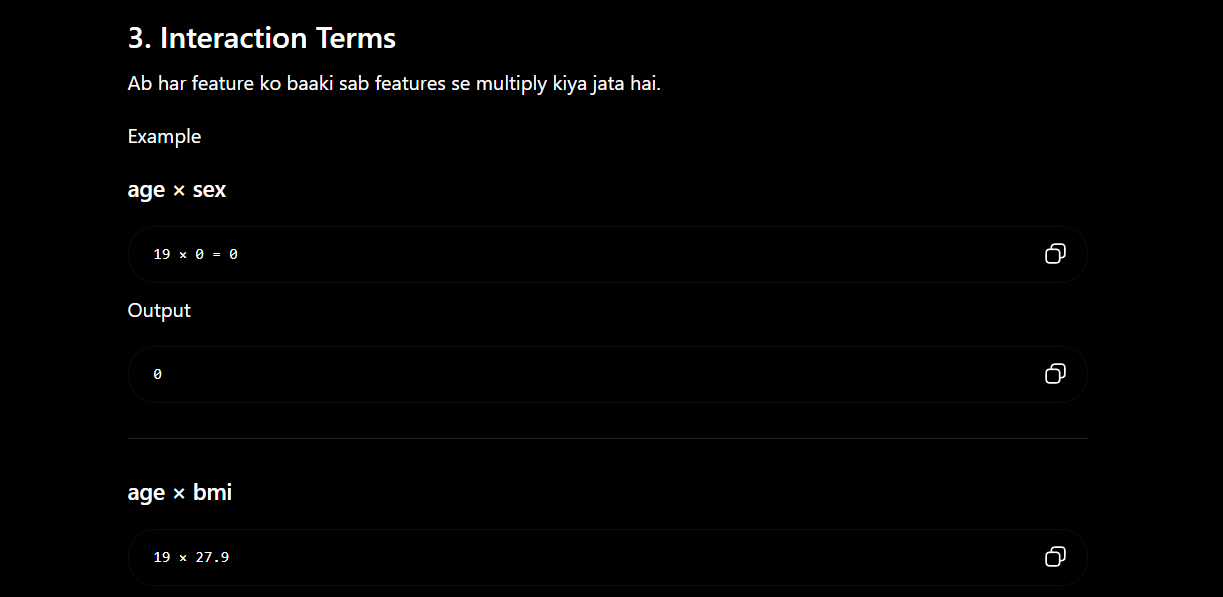

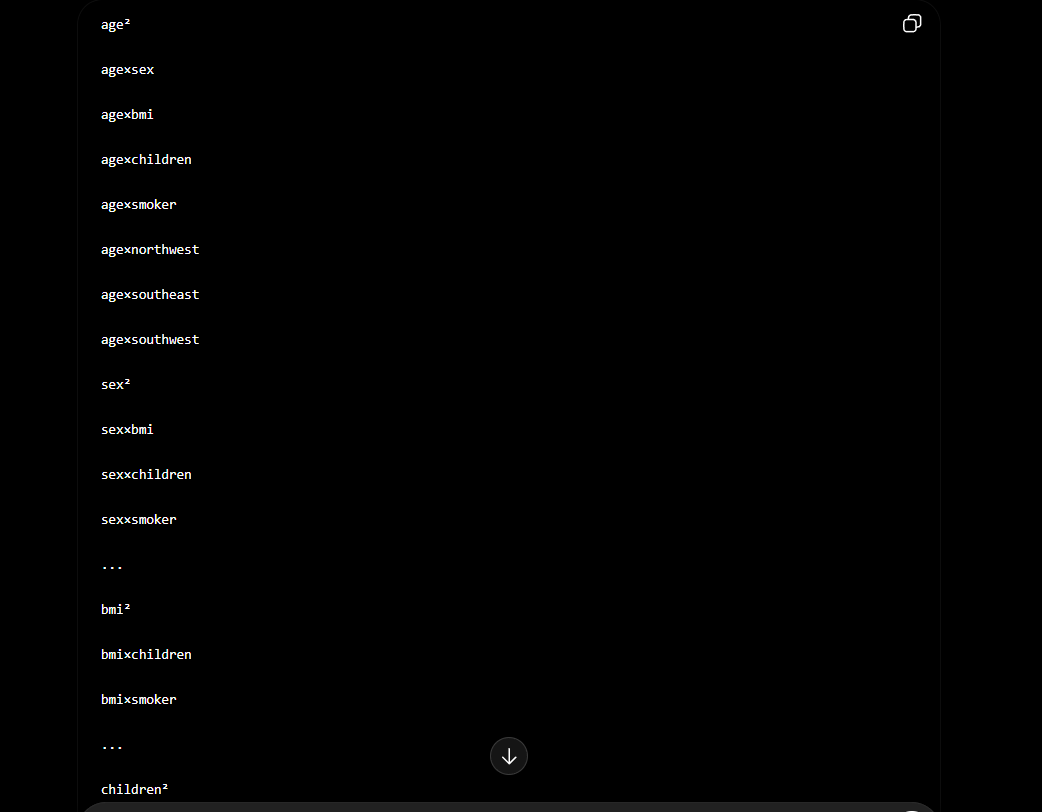

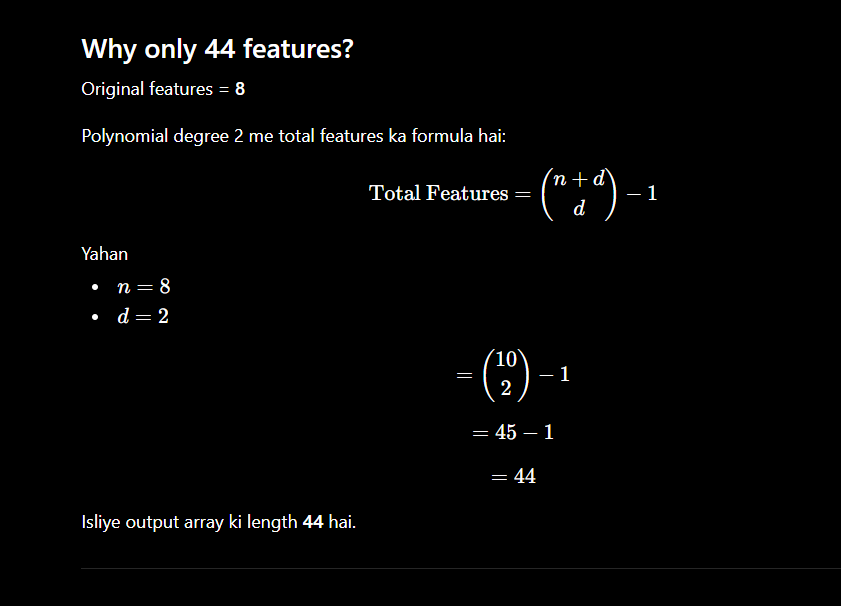

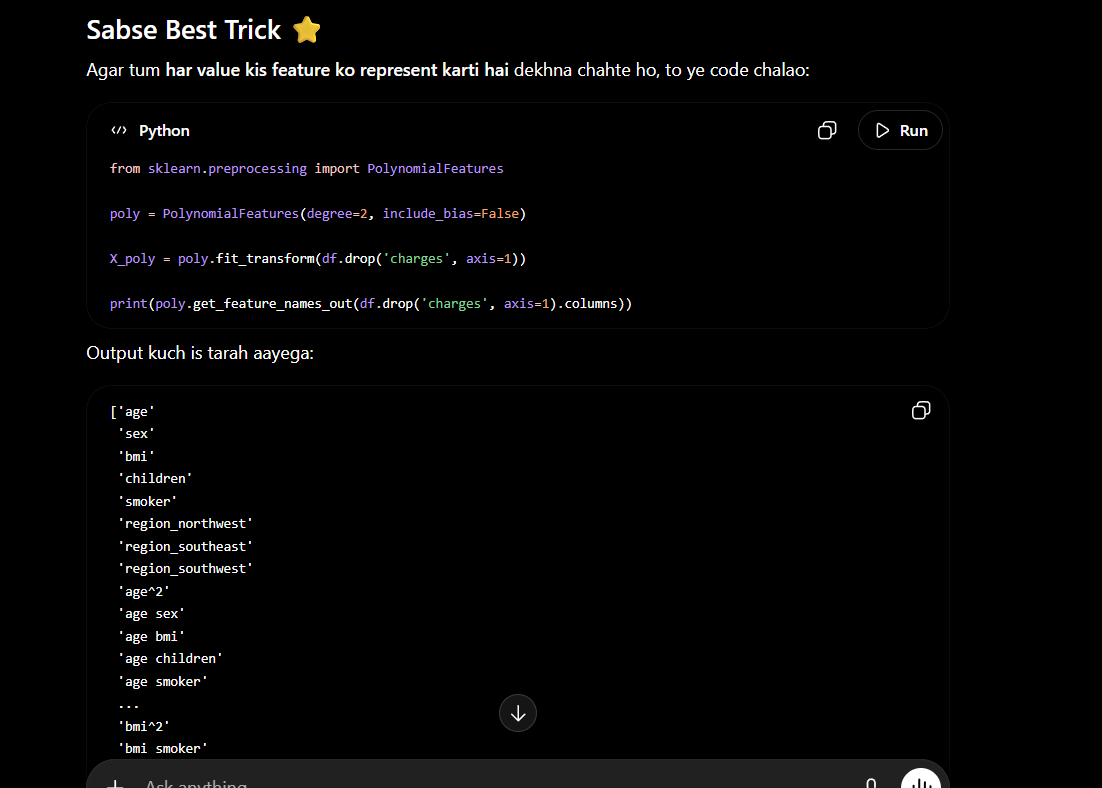

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(df.drop('charges', axis=1))

print(poly.get_feature_names_out(df.drop('charges', axis=1).columns))

['age' 'sex' 'bmi' 'children' 'smoker' 'region_northwest'
 'region_southeast' 'region_southwest' 'age^2' 'age sex' 'age bmi'
 'age children' 'age smoker' 'age region_northwest' 'age region_southeast'
 'age region_southwest' 'sex^2' 'sex bmi' 'sex children' 'sex smoker'
 'sex region_northwest' 'sex region_southeast' 'sex region_southwest'
 'bmi^2' 'bmi children' 'bmi smoker' 'bmi region_northwest'
 'bmi region_southeast' 'bmi region_southwest' 'children^2'
 'children smoker' 'children region_northwest' 'children region_southeast'
 'children region_southwest' 'smoker^2' 'smoker region_northwest'
 'smoker region_southeast' 'smoker region_southwest' 'region_northwest^2'
 'region_northwest region_southeast' 'region_northwest region_southwest'
 'region_southeast^2' 'region_southeast region_southwest'
 'region_southwest^2']


### Second Example 

In [26]:
import pandas as pd 
import numpy as np

In [27]:
df = pd.read_csv('auto-mpg.csv')

In [28]:
df.shape

(398, 9)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [30]:
(df == '?').any()

mpg             False
cylinders       False
displacement    False
horsepower       True
weight          False
acceleration    False
model year      False
origin          False
car name        False
dtype: bool

In [31]:
df[df['horsepower'] == '?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [32]:
df = df.replace('?',np.nan)

In [33]:
df = df.dropna()

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


In [35]:
df['horsepower'] = df['horsepower'].astype('int')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


In [39]:
df = df.drop(columns = 'car name')

In [41]:
df['origin'].value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

In [43]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1
394,44.0,4,97.0,52,2130,24.6,82,2
395,32.0,4,135.0,84,2295,11.6,82,1
396,28.0,4,120.0,79,2625,18.6,82,1


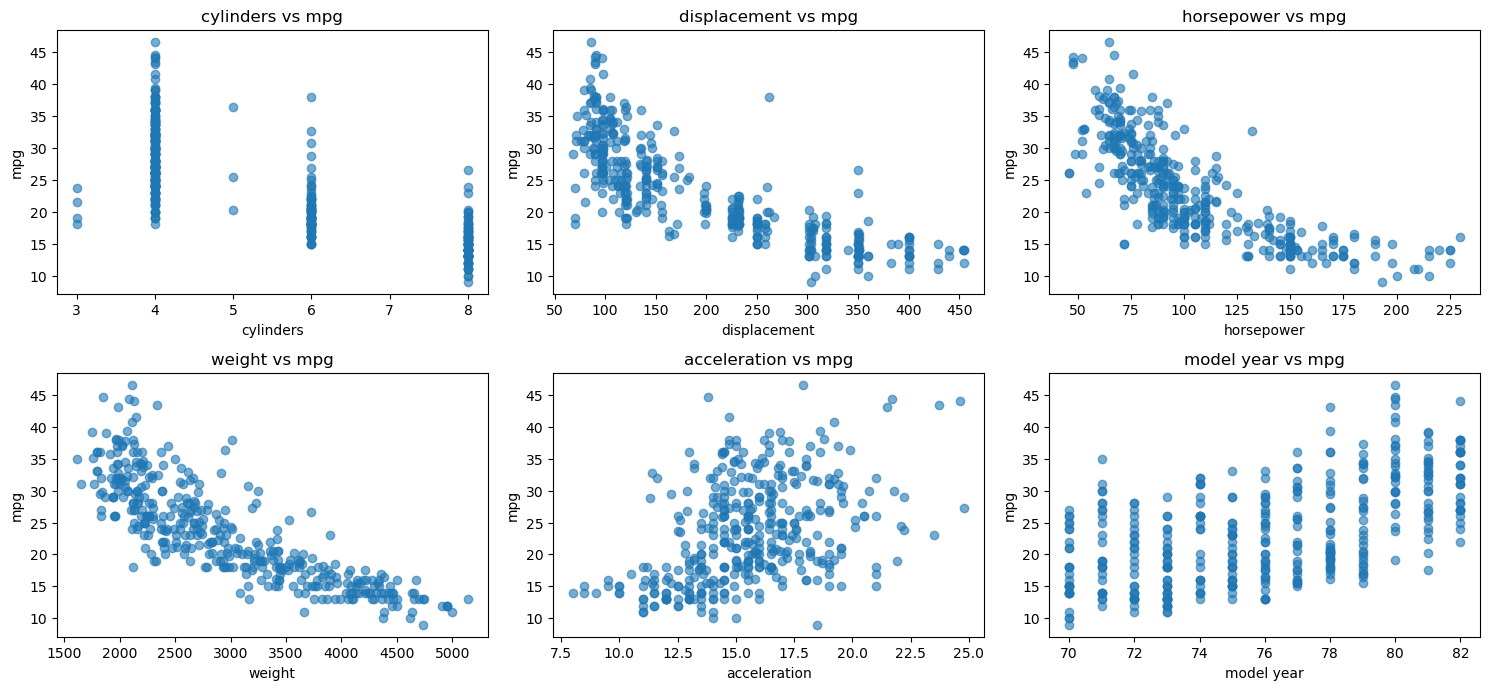

In [45]:
import matplotlib.pyplot as plt

target = 'mpg'

# Target column ko hata do
features = ['cylinders',	'displacement',	'horsepower',	'weight',	'acceleration',	'model year']

# Figure size
plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df[col], df[target], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f'{col} vs {target}')

plt.tight_layout()
plt.show()

In [46]:
df.head(1)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1


In [18]:
df['mpg'].describe()

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [47]:
features = ['cylinders','mpg',	'displacement',	'horsepower',	'weight',	'acceleration',	'model year']
for i in features:
    print(i)
    print(df[i].describe())
    print()
    

cylinders
count    392.000000
mean       5.471939
std        1.705783
min        3.000000
25%        4.000000
50%        4.000000
75%        8.000000
max        8.000000
Name: cylinders, dtype: float64

mpg
count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

displacement
count    392.000000
mean     194.411990
std      104.644004
min       68.000000
25%      105.000000
50%      151.000000
75%      275.750000
max      455.000000
Name: displacement, dtype: float64

horsepower
count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

weight
count     392.000000
mean     2977.584184
std       849.402560
min      1613.000000
25%      2225.250000
50%      2803.500000
75%      3614.750000
max      5140.000000
Name: weight, dty

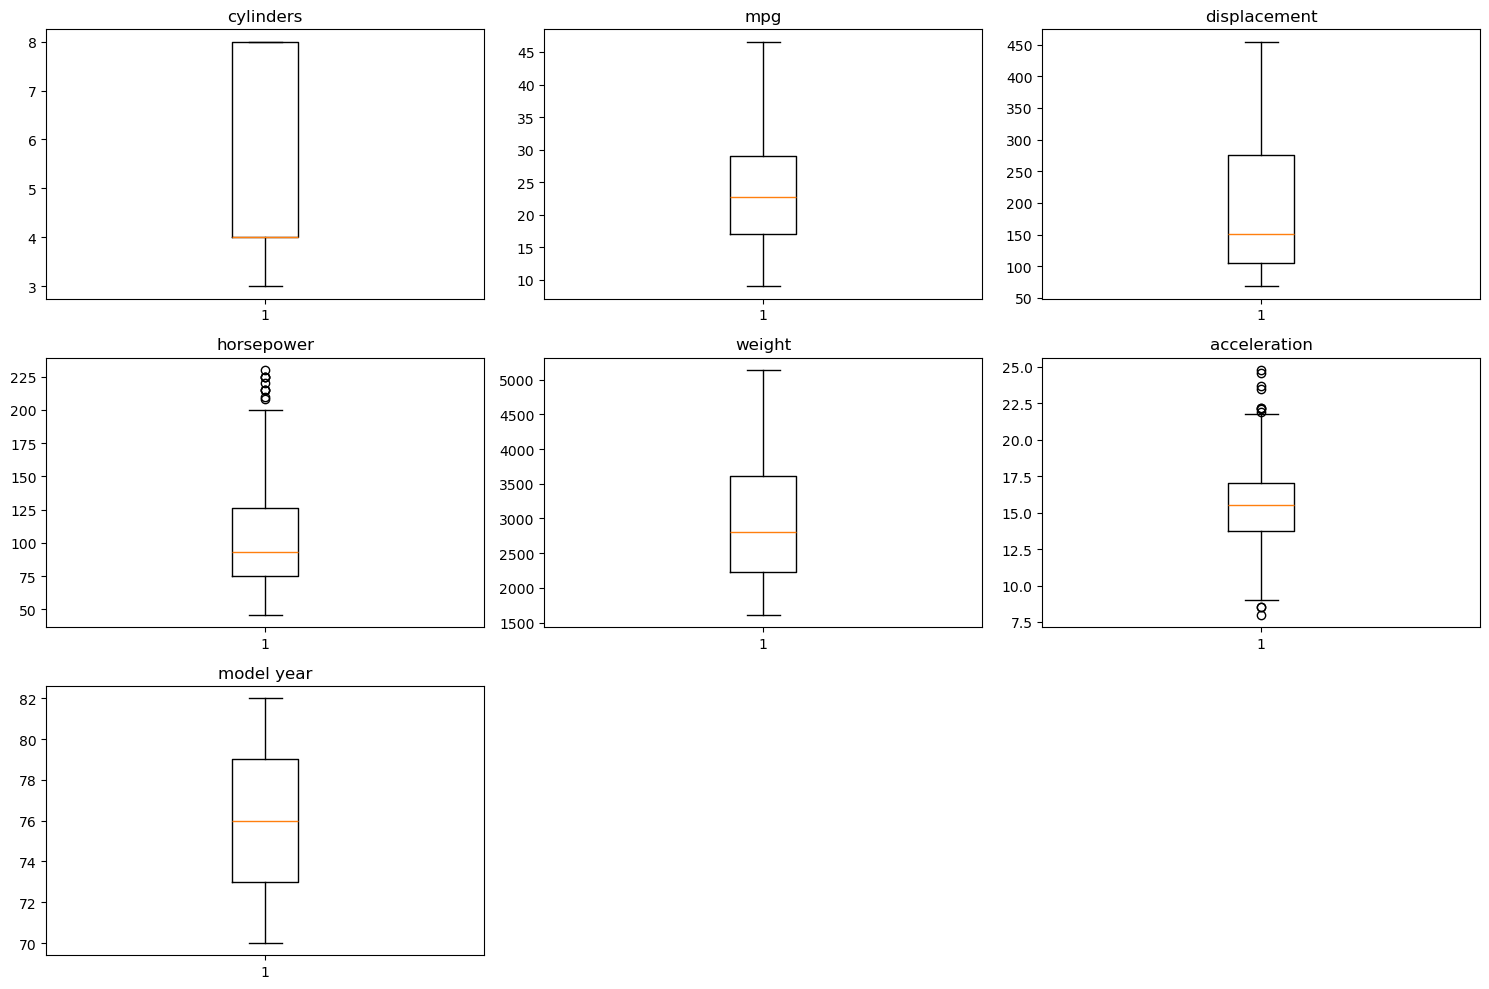

In [48]:
import matplotlib.pyplot as plt

features = ['cylinders','mpg','displacement','horsepower',
            'weight','acceleration','model year']

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(3,3,i)
    plt.boxplot(df[col], vert=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [49]:
X = df.drop(columns = 'mpg')
y = df['mpg']

In [60]:
# first we apply normal normal linear regression

from sklearn.model_selection import cross_val_score,KFold
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
folds = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 13
)

scores = cross_val_score(lr,X,y,cv = folds,scoring = 'r2')
print(scores)
print(scores.mean())

[0.76823818 0.77542045 0.83677647 0.84971301 0.82642075]
0.8113137737620904


In [23]:
# now we apply ploynomial regression

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2,include_bias = False)
X_trans = poly.fit_transform(X)

In [77]:
from sklearn.model_selection import cross_val_score,KFold
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
folds = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 13
)

scores = cross_val_score(lr,X_trans,y,cv = folds,scoring = 'r2')
print(scores)
print(scores.mean())


# after applying polynomial feature accuracy is increased by 4 percent 

[0.80585176 0.86810289 0.86411893 0.88845243 0.86399359]
0.8581039215115019


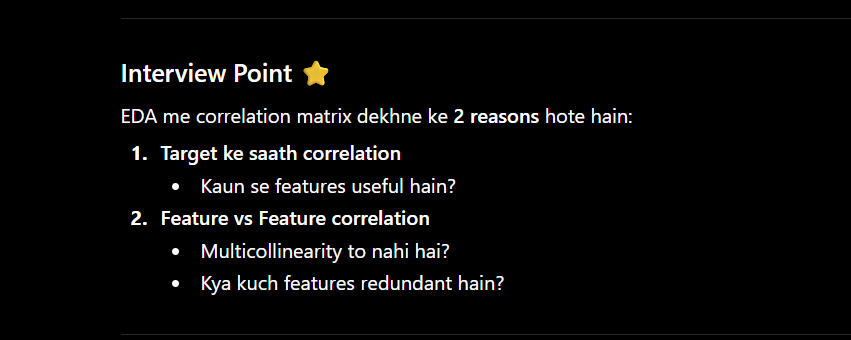

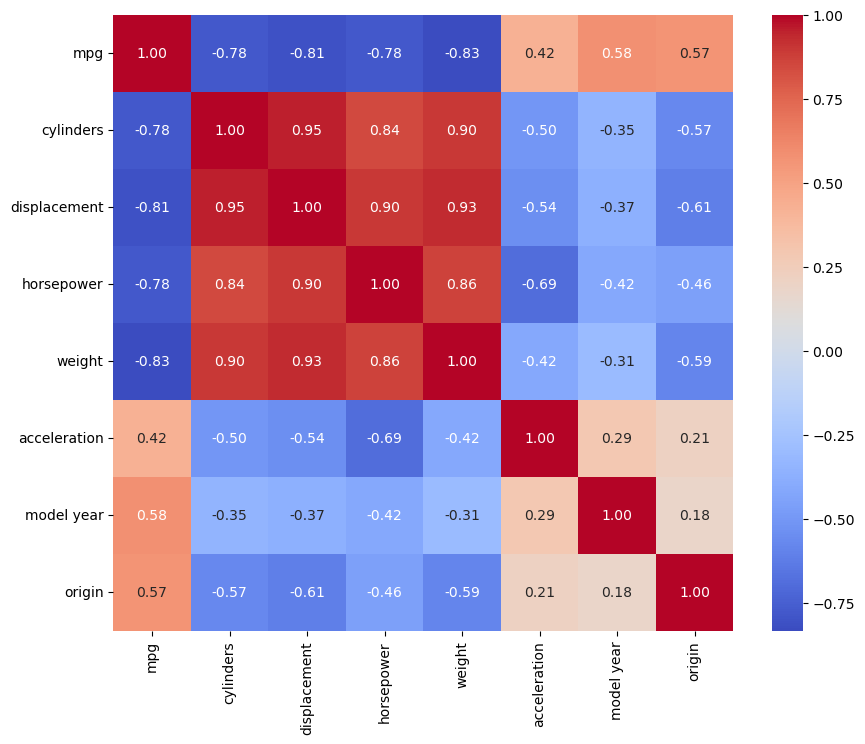

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.show()


# isme bahut saare feature ka dusre feature ke saath high multicoll hai isi 
# wajah se hamari accuracy kam aa rahi hai 